In [1]:
main_llm_dir = '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/'

# full baseline data stored
dir_jsons = '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/jsons/'

In [2]:
from glob import glob
import pickle
import pandas as pd
import json
from copy import deepcopy
import numpy as np
import os

In [3]:
dirs = glob(main_llm_dir + '*')
dirs

['/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/claude_api',
 '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/gemini_api_1.5',
 '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/chatgpt_api']

In [4]:
dirnames = []
for d in dirs:
    dirnames.append(d.split('/')[-1].replace('_api',''))

dirnames

['claude', 'gemini_1.5', 'chatgpt']

In [5]:
# find total overlap of files
files_parsed = []
for d in dirs:
    files = glob(d + '/*.pickle')
    for f in files:
        files_parsed.append(f.split('/')[-1])
files_parsed1 = list(set(files_parsed))
# now check all exist
files_parsed = []
for f in files_parsed1:
    exists = True
    for d in dirs:
        if not os.path.exists(d + '/' + f):
            exists = False
    if exists:
        files_parsed.append(f)

print("there are:", len(files_parsed), 'overlapping files so far')

there are: 112 overlapping files so far


In [7]:
def parse_first_json(text):
    decoder = json.JSONDecoder()
    obj, idx = decoder.raw_decode(text)
    return obj

In [8]:
dfdict = {}
for flag in ['image id', 'question', 'model', 'model id', 'LMM Answer', 'GT Answer']: #, 'plot types']:
    dfdict[flag] = []
for ifile,(dn,dr) in enumerate(zip(dirnames, dirs)):
    print('')
    print('***********', dn, '****************')
    print('')
    for f in files_parsed:
        print("-----------", f, '------------')

        # # read in full data for some extra info
        # with open(dir_jsons + f.removesuffix('.pickle')+'.json', 'r') as f:
        #     j = json.load(f)
        #     jfd = json.loads(j)
        #     import sys; sys.exit()

        with open(dr + '/' + f,'rb') as ff:
            data,  model = pickle.load(ff)

        # loop through q/a
        for qa in data:
            # make row/file
            dfdict['image id'].append(f.removesuffix('.pickle'))
            dfdict['question'].append(qa['question'])
            dfdict['model'].append(dn)
            dfdict['model id'].append(model)
            # try loading response
            try:
                jgt = qa['A']
            except:
                print('no GT answer!')
                import sys; sys.exit()
            # if string/number answer
            if type(jgt) != type({}):
                q = qa['Q'] # {"npoints":""}
                q = q.split('{')[-1].split('}')[0]
                q = q.split(':')[0].replace('"','').replace("'",'')
                #print(q)
                #import sys; sys.exit()
                jgt = {q:jgt}
            # llm
            raw_ans = qa['raw answer']
            jllm = {}
            if '`' not in raw_ans:
                try:
                    jllm = json.loads(raw_ans)
                except:
                    # try splitting
                    if '{' in raw_ans and '}' in raw_ans:
                        a = '{' + raw_ans.split('{')[-1].split('}')[0] + '}'
                        try:
                            jllm = json.loads(a)
                        except:
                            print('could not load answer for non `:', raw_ans)
                            #fslkfjs
                            print('')
                            jllm[list(jgt.keys())[0]] = np.nan
            elif '```json\n' in raw_ans:
                try:
                    a = raw_ans.split('```json\n')[-1].split('```')[0]
                    jllm = json.loads(a)
                except Exception as e:
                    if "Expecting ',' delimiter" in str(e):
                        print('[ERROR]: json decode error -- ', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                        print('')
                    elif 'Unterminated string' in str(e):
                        print('[ERROR]: json decode error -- ', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                        print('')
                    elif 'Expecting value:' in str(e):
                        print('[ERROR]: json decode error -- ', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                        print('')
                    elif 'Invalid \\escape' in str(e):
                        try:
                            a = raw_ans.split('```json\n')[-1].split('```')[0]
                            a = a.replace('\\\\', '\\')
                            jllm = json.loads(a)
                        except Exception as e2:
                            print('[ERROR]: json decode error, t2 -- ', str(e2))
                            if 'Invalid \\escape' in str(e2):
                                jllm[list(jgt.keys())[0]] = np.nan
                            else:
                                fjffj
                    elif 'Extra data:' in str(e):
                        try:
                            jllm = parse_first_json(raw_ans.split('```json\n')[-1].split('```')[0])
                        except Exception as e2:
                            print('[ERROR]: json decode error --', str(e2))
                            jllm[list(jgt.keys())[0]] = np.nan
                    elif 'Expecting property name enclosed in double quotes:' in str(e):
                        print('[ERROR]: json decode error --', str(e))
                        jllm[list(jgt.keys())[0]] = np.nan
                    else:
                        print('could not load answer, 2:', raw_ans)
                        sljfsl
            else:
                print('not sure:')
                print(raw_ans)
                import sys; sys.exit()

            # known issues
            if 'titles' in jllm:
                j2 = {'title':jllm['titles']}
                jllm = deepcopy(j2)
            if 'aspect ratio' in jllm:
                if ':' in jllm['aspect ratio']:
                    ar = float(jllm['aspect ratio'].split(':')[0])/float(jllm['aspect ratio'].split(':')[1])
                    jllm['aspect ratio'] = ar

            # test for matching keys
            for k,v in jgt.items():
                if k not in jllm:
                    print('missing key:', k)
                    print('question format:', qa['format'])
                    print('GT:', jgt)
                    print('LMM:', jllm)
                    jllm[k] = np.nan
                    #import sys; sys.exit()
                elif type(jllm[k]) != type(v):
                    if jllm[k] is None:
                        continue
                    try:
                        a = type(v)(jllm[k])
                        #print('type', type(v), 'for', jllm[k])
                        jllm[k] = a
                    except:
                        try:
                            x = np.isnan(jllm[k])
                        except:
                            try:
                                x = jllm[k].split(' ')[-1]
                                a = type(v)(x)
                                jllm[k] = a
                            except:
                                print('different types of values:')
                                print('GT:', v, type(v))
                                print('LLM:', jllm[k], type(jllm[k]))
                                if type(jllm[k]) == type(''):
                                    jllm[k] = None
                                else:
                                    laksjl
                        #import sys; sys.exit()
            # drop non-presents
            jllm_tmp = deepcopy(jllm)
            for k,v in jllm_tmp.items():
                if k not in jgt:
                    del jllm[k]

            dfdict['LMM Answer'].append(jllm)
            dfdict['GT Answer'].append(jgt)
                
            
df = pd.DataFrame(dfdict)


*********** claude ****************

----------- Picture145.pickle ------------
----------- Picture198.pickle ------------
----------- Picture191.pickle ------------
[ERROR]: json decode error --  Expecting ',' delimiter: line 1 column 436 (char 435)

----------- Picture168.pickle ------------
----------- Picture136.pickle ------------
----------- Picture6.pickle ------------
----------- Picture138.pickle ------------
----------- Picture153.pickle ------------
----------- Picture92.pickle ------------
----------- Picture161.pickle ------------
----------- Picture196.pickle ------------
----------- Picture46.pickle ------------
----------- Picture5.pickle ------------
----------- Picture10.pickle ------------
----------- Picture7.pickle ------------
----------- Picture67.pickle ------------
----------- Picture20.pickle ------------
----------- Picture135.pickle ------------
----------- Picture30.pickle ------------
----------- Picture66.pickle ------------
----------- Picture120.pickle

In [9]:
df.head()

,image id,question,model,model id,LMM Answer,GT Answer
0,Picture145,How many panels are in this figure?,claude,claude-sonnet-4-20250514,"{'nrows': 1, 'ncols': 2}","{'nrows': 1, 'ncols': 2}"
1,Picture145,What is the plot style used in this figure?,claude,claude-sonnet-4-20250514,{'plot style': 'ggplot'},{'plot style': 'Solarize_Light2'}
2,Picture145,What is the colormap that was used in this fig...,claude,claude-sonnet-4-20250514,{'colormap': 'viridis'},{'colormap': 'gray'}
3,Picture145,What is the aspect ratio of this figure?,claude,claude-sonnet-4-20250514,{'aspect ratio': 1.0},{'aspect ratio': 0.4521328929757427}
4,Picture145,What are the titles for each figure panel?,claude,claude-sonnet-4-20250514,"{'title': ['', '']}","{'title': ['', '']}"


## Making tables

e.g.

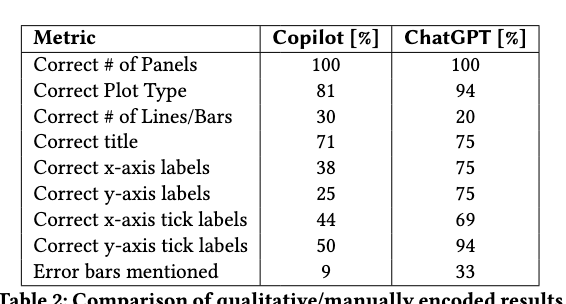

In [10]:
df['question'].unique()

array(['How many panels are in this figure?',
       'What is the plot style used in this figure?',
       'What is the colormap that was used in this figure?',
       'What is the aspect ratio of this figure?',
       'What are the titles for each figure panel?',
       'What are the x-axis titles for each figure panel?',
       'What are the values for each of the tick marks on the x-axis?',
       'What are the values for each of the tick marks on the y-axis?',
       'What are the plot types for each panel in the figure?',
       'What are the matplotlib linestyles in this figure panel?',
       'How many lines are there in the specified figure panel?',
       'How many scatter points are there in the specified figure panel?',
       'What is the mean value of the data along the color-axis in this figure panel? ',
       'What is the mean value of the data along the x-axis in this figure panel? ',
       'What is the mean value of the data along the y-axis in this figure panel? ',


In [11]:
def calc_iqr(diff1):
    q1 = np.percentile(diff1, 25)
    q3 = np.percentile(diff1, 75)
    iqr = q3 - q1
    return iqr

In [ ]:
questions = [
    {'tag':'# panels', 'question':'How many panels are in this figure?', 'type':'special'},
    {'tag':'plot type', 'question':'What is the plot style used in this figure?', 'type':'binary string'}
]

# dftable = {'question':[]}
# for m in df['model'].unique():
#     dftable

for q in questions:
    dfsub = df[df['question']==q['question']]
    models = {}
    for model in dfsub['model'].unique():
        dfsub2 = dfsub[dfsub['model']==model]
        if q['tag'] == '# panels': # something special
            gt = []
            for g in dfsub2['GT Answer'].values:
                gt.append(g['nrows']*g['ncols'])
            lmm = []
            for l in dfsub2['LMM Answer'].values:
                lmm.append(l['nrows']*l['ncols'])
            calc = np.abs(np.array(gt)-np.array(lmm))
            models[model] = {'mean diff': np.mean(calc), 'median diff':np.median(calc),
                             'std diff':np.std(calc), 'iqr diff':calc_iqr(calc)}
        elif q['type'] == 'binary string':
            gt = []; lmm = []
            for v in dfsub2['GT Answer'].values:
                gt.append(list(v.values())[0].lower())
            gt = np.array(gt)
            for v in dfsub2['LMM Answer'].values:
                lmm.append(list(v.values())[0].lower())
            lmm = np.array(lmm)
            import sys; sys.exit()
            
        else:
            print(q['tag'])
            import sys; sys.exit()
    q['answers'] = deepcopy(models)

    #import sys; sys.exit()


SystemExit: 

/opt/anaconda3/envs/JCDL2025/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [21]:
lmm

array(['ggplot', 'classic', 'seaborn', 'ggplot', 'classic', 'seaborn',
       'classic', 'classic', 'classic', 'classic', 'classic', 'classic',
       'seaborn', 'classic', 'classic', 'classic', 'classic', 'seaborn',
       'classic', 'classic', 'classic', 'ggplot', 'classic', 'classic',
       'classic', 'classic', 'classic', 'dark_background', 'classic',
       'ggplot', 'dark_background', 'classic', 'seaborn', 'classic',
       'seaborn', 'seaborn', 'seaborn', 'classic', 'classic', 'classic',
       'classic', 'classic', 'classic', 'classic', 'seaborn', 'seaborn',
       'ggplot', 'classic', 'seaborn', 'classic', 'classic', 'classic',
       'ggplot', 'classic', 'classic', 'seaborn', 'classic', 'classic',
       'classic', 'classic', 'classic', 'ggplot', 'classic', 'classic',
       'classic', 'classic', 'classic', 'classic', 'classic', 'classic',
       'classic', 'classic', 'seaborn', 'ggplot', 'classic',
       'dark_background', 'classic', 'classic', 'classic', 'classic',
      

In [98]:
calc

array([ 0,  0,  0,  0,  0,  5, 11,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0,
        1,  4,  1,  0,  0,  0, 27,  0,  2,  0,  0,  0,  0,  0,  3,  0,  0,
        0,  0,  0,  0,  0,  1,  3,  0,  1,  3,  0,  0,  0, 14,  0,  5,  0,
        0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, 35,  1,  4,  1,  0,  4,  0,  0,  0,  4,  0,  0,  0,  0,  0,
        0,  1,  0,  0,  0,  0,  2,  0,  0,  1, 24,  0,  2,  0,  0,  0,  0])